# Notebook 04 — Deep Dive: Hierarchical Methods
Dendrograms for Ward vs Complete linkage, cut-height analysis, memory profiling.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import time
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

from src.datasets import load_penguins, load_wine_data, load_digits_subset
from src.metrics import compute_all_metrics
from src.visualisation import plot_dendrogram

os.makedirs('../outputs/figures', exist_ok=True)

In [2]:
x_pen, y_pen = load_penguins()
x_wine, y_wine = load_wine_data()
x_dig, y_dig = load_digits_subset()
print(f'penguins: {x_pen.shape}, wine: {x_wine.shape}, digits: {x_dig.shape}')

penguins: (333, 4), wine: (178, 13), digits: (901, 64)


## Dendrograms — Ward vs Complete vs Average

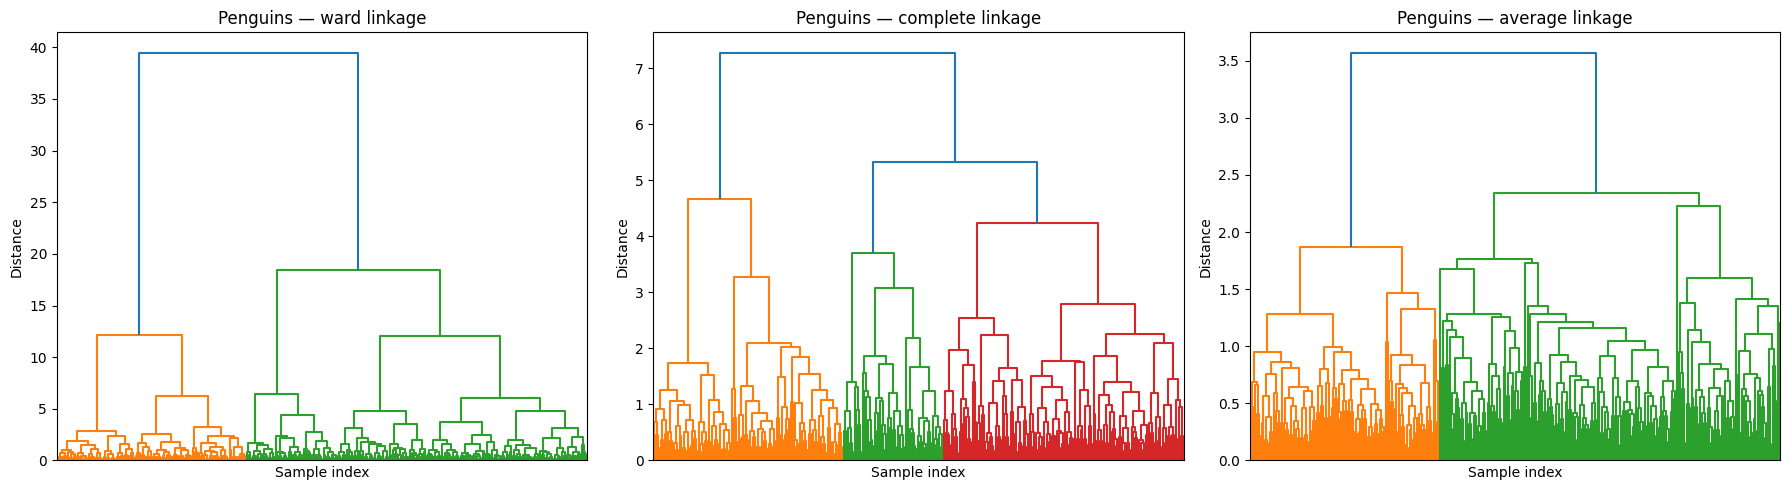

Saved 04_dendrograms_penguins.png


In [3]:
methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, method in zip(axes, methods):
    plot_dendrogram(x_pen, method=method, ax=ax)
    ax.set_title(f'Penguins — {method} linkage')
plt.tight_layout()
plt.savefig('../outputs/figures/04_dendrograms_penguins.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved 04_dendrograms_penguins.png')

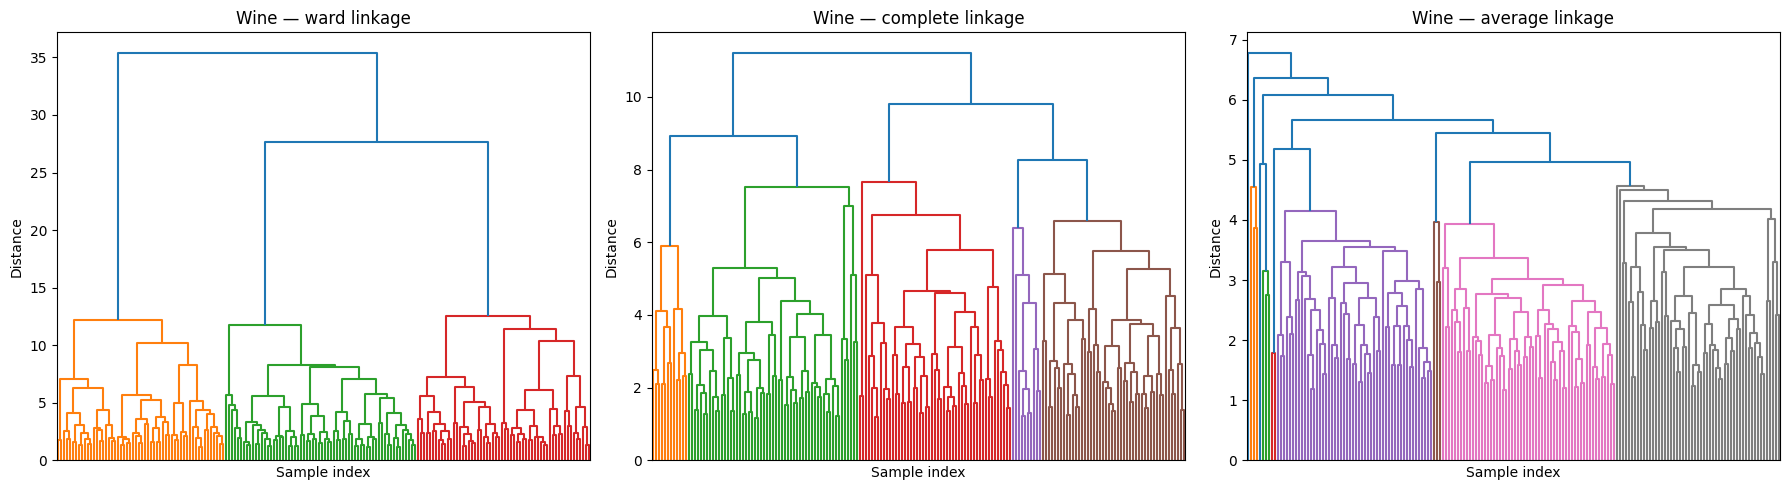

Saved 04_dendrograms_wine.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, method in zip(axes, methods):
    plot_dendrogram(x_wine, method=method, ax=ax)
    ax.set_title(f'Wine — {method} linkage')
plt.tight_layout()
plt.savefig('../outputs/figures/04_dendrograms_wine.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved 04_dendrograms_wine.png')

## Cut-height vs cluster count (Ward, penguins)

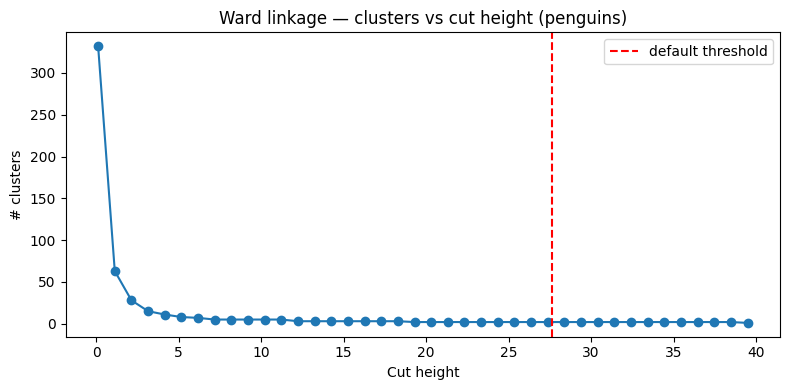

In [5]:
z = linkage(x_pen, method='ward')
heights = np.linspace(z[:, 2].min(), z[:, 2].max(), 40)
n_clusters_at_height = [len(np.unique(fcluster(z, t=h, criterion='distance'))) for h in heights]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(heights, n_clusters_at_height, 'o-')
ax.axvline(x=z[:, 2].max() * 0.7, color='red', linestyle='--', label='default threshold')
ax.set_xlabel('Cut height')
ax.set_ylabel('# clusters')
ax.set_title('Ward linkage — clusters vs cut height (penguins)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/04_cut_height.png', dpi=100, bbox_inches='tight')
plt.show()

## ARI comparison: Ward vs Complete across k

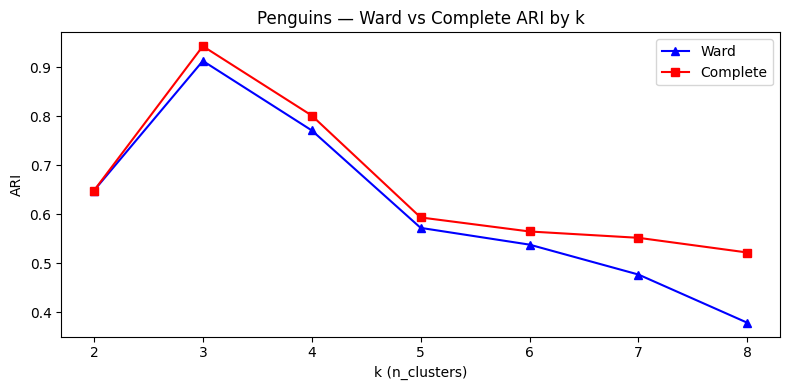

In [6]:
k_range = range(2, 9)
ward_aris = [compute_all_metrics(x_pen, y_pen, AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(x_pen))['ari'] for k in k_range]
comp_aris = [compute_all_metrics(x_pen, y_pen, AgglomerativeClustering(n_clusters=k, linkage='complete').fit_predict(x_pen))['ari'] for k in k_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), ward_aris, 'b^-', label='Ward')
ax.plot(list(k_range), comp_aris, 'rs-', label='Complete')
ax.set_xlabel('k (n_clusters)')
ax.set_ylabel('ARI')
ax.set_title('Penguins — Ward vs Complete ARI by k')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/04_ward_vs_complete.png', dpi=100, bbox_inches='tight')
plt.show()

## Runtime profiling across datasets

 dataset  linkage  runtime_sec       ari
penguins     ward     0.005553  0.913240
penguins complete     0.002833  0.943353
penguins  average     0.002930  0.943246
    wine     ward     0.001579  0.789933
    wine complete     0.001471  0.577144
    wine  average     0.001726 -0.005442
  digits     ward     0.035462  0.538083
  digits complete     0.026644 -0.000004
  digits  average     0.027876  0.000014


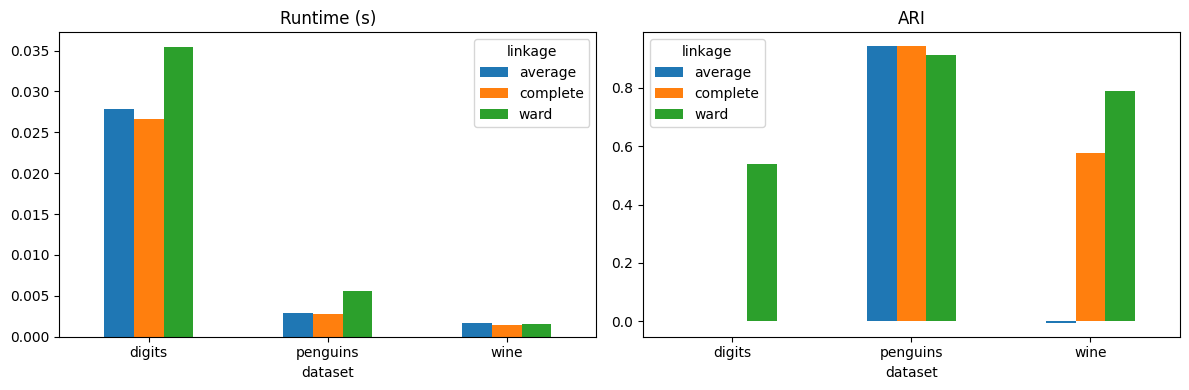

In [7]:
import pandas as pd
rt_rows = []
for ds_name, x, y in [('penguins', x_pen, y_pen), ('wine', x_wine, y_wine), ('digits', x_dig, y_dig)]:
    for method in ['ward', 'complete', 'average']:
        t0 = time.perf_counter()
        labels = AgglomerativeClustering(n_clusters=3, linkage=method).fit_predict(x)
        rt = time.perf_counter() - t0
        ari = compute_all_metrics(x, y, labels)['ari']
        rt_rows.append({'dataset': ds_name, 'linkage': method, 'runtime_sec': rt, 'ari': ari})

df_rt = pd.DataFrame(rt_rows)
print(df_rt.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pivot_rt = df_rt.pivot(index='dataset', columns='linkage', values='runtime_sec')
pivot_ari = df_rt.pivot(index='dataset', columns='linkage', values='ari')
pivot_rt.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Runtime (s)')
pivot_ari.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('ARI')
plt.tight_layout()
plt.savefig('../outputs/figures/04_linkage_comparison.png', dpi=100, bbox_inches='tight')
plt.show()